# Ejemplo de uso: línea DINÁMICA (`src.dynamic`)

Notebook autocontenido para comprobar que la refactorización funciona y
ver el flujo completo del motor dinámico:
**parámetros → red → motor → `run()` → figuras, observables y comprobaciones.**

| Pieza | Clase refactorizada | Origen | Alias heredado |
|---|---|---|---|
| Parámetros | `KMCParamsDynamic` | `params.py` | `KMCParams` |
| Red SOS | `LatticeSOSDynamic` | `lattice.py` | `LatticeSOS` |
| Motor BKL | `KMC_BKL_Dynamic` | `bkl.py` | `KMC_BKL` |

**Qué caracteriza a esta línea**
- La sobresaturación **evoluciona**: S = ln(C/C_eq) con C = N_bulk/V. Cada adsorción
  saca una partícula del reservorio y cada desorción la devuelve, así que el
  crecimiento se frena a medida que N_bulk se acerca a V·C_eq (S → 0).
- Es isotrópica: una sola `E_pb_over_kT` y una sola `delta`.
- `run()` devuelve **solo** `snaps`, sin `stats`. El historial de eventos está en
  `kmc.history` y los contadores en `kmc.counts`.
- `fixed_sigma` no es un campo del dataclass: se puede asignar como atributo
  (`params.fixed_sigma = ...`) y en esta línea se interpreta como **S**, no como σ (en
  la línea estática es σ).
- `conversion_percent` = N_inc/(N_bulk + N_inc) cuenta **eventos de incorporación**, que
  no cambian las alturas (punto pendiente de física, `README.md` §8). La masa en la red
  es otro observable y se muestra aparte.

**Colores de las morfologías** (estilo `"paper"` del `Plotter`, como la Fig. 9 de
Nagpal et al. 2024, `references/modern_kMC/`):
- **azul**: capa completamente llena (todos los niveles por debajo de `min(heights)`);
- **rojo**: capa en crecimiento (todo lo que está por encima).

Tiempo de ejecución estimado: 1–3 min (red 30×30, unos 6000 eventos). Todo se muestra
en las celdas; lo único que se escribe a disco es el GIF, en una carpeta temporal.

## 1. Imports

In [2]:
%matplotlib inline
import copy
import sys
import tempfile
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display   # solo para mostrar el GIF en la celda

# Busca la carpeta que CONTIENE src/ (la raíz del repo) subiendo desde el directorio actual:
# funciona con el notebook abierto desde notebooks/ o desde la raíz del repo.
_candidatos = [Path.cwd(), *Path.cwd().parents]
REFAC = next(p for p in _candidatos if (p / "src" / "static" / "engine.py").exists())
if str(REFAC) not in sys.path:
    sys.path.insert(0, str(REFAC))

from src.dynamic import KMC_BKL_Dynamic, KMCParamsDynamic, LatticeSOSDynamic
from src.plotting import Plotter
from src.common.observables import count_by_coordination, mean_height, roughness, step_density

print("Código importado desde:", REFAC / "src")
print("numpy", np.__version__)

Código importado desde: /home/sggphysics/kMC_Malaria/src
numpy 2.5.3


## 2. Parámetros

Valores de `scripts/configs/dynamic_final_results.json` (antes
`notebooks/final_results.ipynb`, sección "Concentración dinámica").

| Parámetro | Significado |
|---|---|
| `T` | temperatura (solo informativa; las energías ya van divididas por kT) |
| `K0_plus` | prefactor de adsorción, desorción y migración |
| `K_inc_plus` | prefactor de incorporación |
| `E_pb_over_kT` | energía de enlace lateral / kT |
| `phi_over_kT` | energía de superficie / kT |
| `delta` | parámetro adaptativo de la adsorción |
| `V`, `C_eq` | volumen del reservorio y concentración de equilibrio |
| `S_floor`, `S_ceil` | límites de S |

In [3]:
params = KMCParamsDynamic(
    T=300,
    K0_plus=11.671806264584635,
    K_inc_plus=0.5069325183371898,
    E_pb_over_kT=1.2704636027368605,
    phi_over_kT=1.4792478012079329,
    delta=1.7789686274068774,
    V=0.9943756704678864,
    C_eq=6.66285823642452,
    S_floor=-5.0,
    S_ceil=8.0,
)
params

KMCParamsDynamic(T=300, K0_plus=11.671806264584635, K_inc_plus=0.5069325183371898, E_pb_over_kT=1.2704636027368605, phi_over_kT=1.4792478012079329, delta=1.7789686274068774, V=0.9943756704678864, C_eq=6.66285823642452, S_floor=-5.0, S_ceil=8.0)

## 3. Red y motor

El config original usa una red de 70×70 con N_bulk0 = 3000 y 100 semillas. Aquí la red
es de 30×30 y se mantiene la misma densidad de reservorio y de semillas por sitio. Las
semillas son adátomos aleatorios que el motor coloca al crearse y que se descuentan
del reservorio.

`LatticeSOSDynamic.initialize(...)` admite `"flat"` y `"random_surface"`.

In [4]:
L = 30
N_BULK0 = round(3000 * L * L / 70**2)    # ≈ 551 partículas en el reservorio
N_SEMILLAS = round(100 * L * L / 70**2)  # ≈ 18 adátomos iniciales


def crear_motor() -> KMC_BKL_Dynamic:
    """Red + motor con semillas fijas: misma trayectoria cada vez que se llama."""
    lat = LatticeSOSDynamic(size=(L, L), seed=25)
    lat.initialize("flat")
    return KMC_BKL_Dynamic(lat, params, N_bulk0=N_BULK0, rng_seed=123,
                           time_scale=1200, n_seeds=N_SEMILLAS)


kmc = crear_motor()
print(f"S inicial = {kmc.supersaturation:.3f}")
print(f"Partículas en la red: {kmc.lat.heights.sum()} | en el reservorio: {kmc.N_bulk}")
print(f"El crecimiento neto se detiene cuando N_bulk ≈ V·C_eq = {params.V * params.C_eq:.1f} (S = 0)")

S inicial = 4.388
Partículas en la red: 18 | en el reservorio: 533
El crecimiento neto se detiene cuando N_bulk ≈ V·C_eq = 6.6 (S = 0)


## 4. ¿Hasta qué tiempo simular?

Una corrida piloto corta sobre una **copia** del motor (no altera `kmc` ni su generador
aleatorio) da el tiempo medio por evento al principio. En esta línea las tasas bajan
a medida que se agota el reservorio, así que la estimación es aproximada; `max_events`
pone el tope de coste.

In [5]:
N_EVENTOS = 6000    # súbelo para ver más evolución (el coste crece de forma lineal)

piloto = copy.deepcopy(kmc)
piloto.run(t_end=np.inf, max_events=300)
dt_evento = piloto.t / 300
T_END = dt_evento * N_EVENTOS
print(f"≈ {dt_evento:.3e} u.t. por evento al inicio  ->  T_END ≈ {T_END:.4g} u.t.")

≈ 6.134e-04 u.t. por evento al inicio  ->  T_END ≈ 3.68 u.t.


## 5. Simulación

`run(t_end, snapshot_times, max_events)` devuelve una lista de tuplas
`(t, heights, conversion_percent)`. Si se llega a `max_events` antes de `t_end`, los
snapshots que faltan se rellenan con el estado final.

In [6]:
snapshot_times = np.linspace(0, T_END, 9)

t0 = time.perf_counter()
snaps = kmc.run(t_end=T_END, snapshot_times=snapshot_times, max_events=3 * N_EVENTOS)
duracion = time.perf_counter() - t0

n_eventos = len(kmc.history)
print(f"Cómputo: {duracion:.1f} s ({1e3 * duracion / max(n_eventos, 1):.2f} ms/evento)")
print(f"Tiempo simulado: {kmc.t:.4g} u.t. (objetivo {T_END:.4g})")
print(f"Eventos totales: {n_eventos}")
for evento, n in kmc.counts.items():
    print(f"   {evento:<14s}{n:>8d}")
print(f"S final = {kmc.supersaturation:.3f} | N_bulk final = {kmc.N_bulk}")
print(f"conversion_percent = {kmc.conversion_percent:.2f} %  (eventos de incorporación)")
if kmc.t < T_END:
    print("⚠️ Se alcanzó max_events antes de T_END: los últimos snapshots repiten el estado final.")

Cómputo: 4.0 s (6.81 ms/evento)
Tiempo simulado: 3.743 u.t. (objetivo 3.68)
Eventos totales: 592
   adsorption         537
   desorption          11
   migration           26
   incorporation       18
S final = 0.055 | N_bulk final = 7
conversion_percent = 83.72 %  (eventos de incorporación)


## 6. Morfología (estilo del artículo)

`Plotter(kmc, style="paper")`: azul = capa completa, rojo = capa en crecimiento. En
esta línea σ cambia con el tiempo, así que el título no la muestra (el σ actual del
motor no sería el de cada snapshot).

🧩 Usando último snapshot disponible: t=3.680 (conv=83.72%)


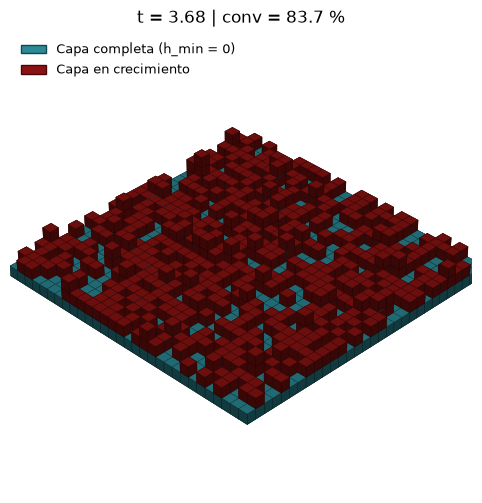

In [7]:
plotter = Plotter(kmc, style="paper")
plotter.plot_crystal_3d(snapshots=snaps)

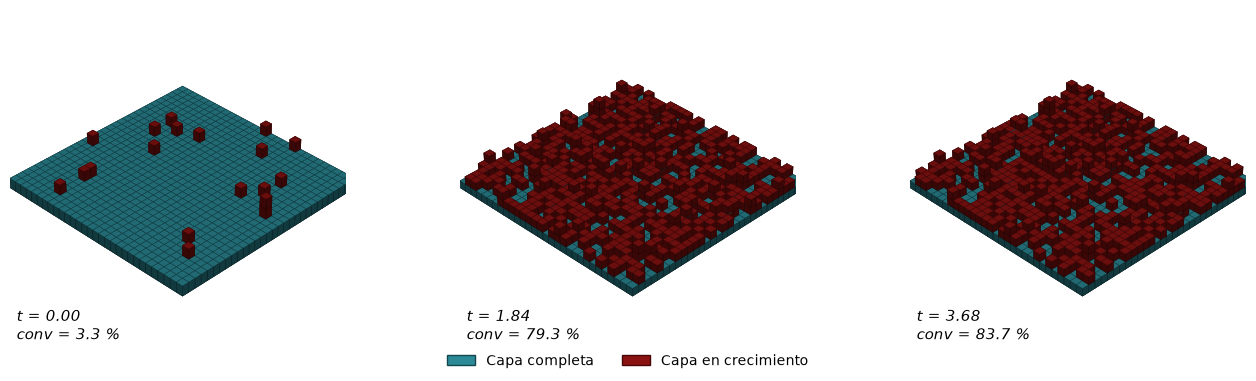

In [8]:
plotter.plot_morphology_sequence(snaps, n_panels=3)

Los estilos antiguos siguen disponibles. Por ejemplo, `classic` era el que usaba
`final_results.ipynb` para esta línea:

🧩 Usando último snapshot disponible: t=3.680 (conv=83.72%)


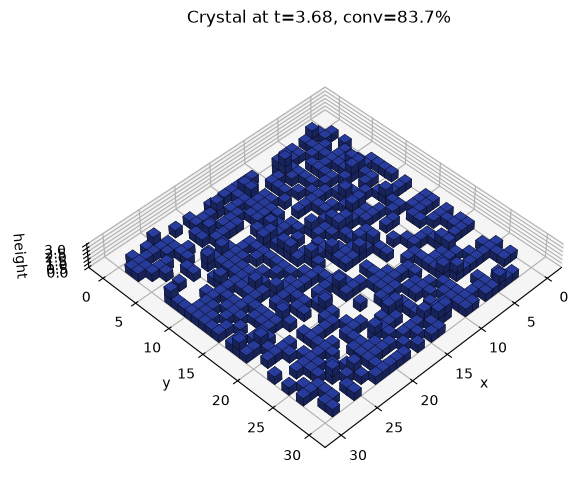

In [9]:
Plotter(kmc, style="classic").plot_crystal_3d(mode="voxel", snapshots=snaps)

## 7. Observables

Esta línea no devuelve `stats`, pero la evolución se reconstruye con `kmc.history`: la
masa en la red cambia +1 en cada adsorción y −1 en cada desorción, y por conservación
N_bulk = N_bulk0 − masa. Con eso se obtiene S(t) evento a evento.

In [10]:
h = kmc.lat.heights
print(f"Altura media           : {mean_height(h):.3f} capas")
print(f"Rugosidad (std de h)   : {roughness(h):.3f}")
print(f"Densidad de escalones  : {step_density(kmc.lat):.3f}")
print(f"Sitios por coordinación: {count_by_coordination(kmc.lat)}")

Altura media           : 0.604 capas
Rugosidad (std de h)   : 0.603
Densidad de escalones  : 0.233
Sitios por coordinación: {0: 43, 1: 114, 2: 169, 3: 124, 4: 450}


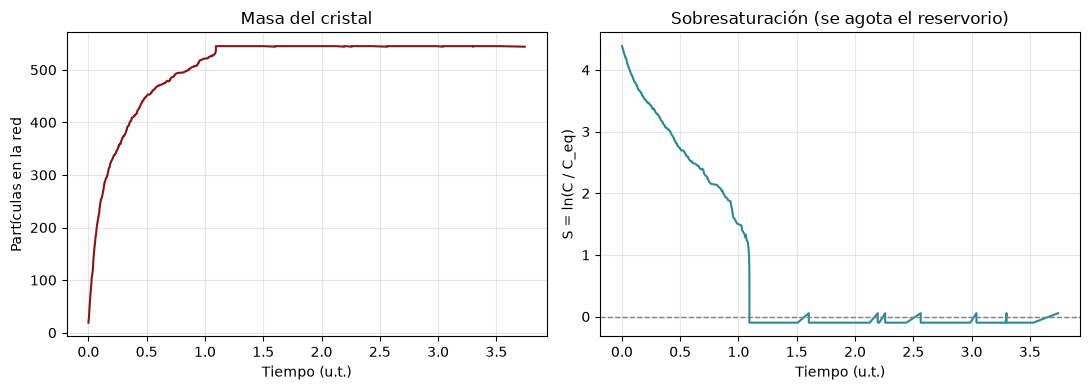

In [11]:
# Evolución evento a evento reconstruida desde el historial
t_ev = np.array([t for t, _, _ in kmc.history])
tipo = np.array([e for _, e, _ in kmc.history])
masa_ev = N_SEMILLAS + np.cumsum((tipo == "adsorption").astype(int)
                                 - (tipo == "desorption").astype(int))
N_bulk_ev = N_BULK0 - masa_ev
S_ev = np.clip(np.log((N_bulk_ev / params.V + 1e-15) / params.C_eq), params.S_floor, params.S_ceil)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(t_ev, masa_ev, color="#8B1212")
ax1.set_xlabel("Tiempo (u.t.)")
ax1.set_ylabel("Partículas en la red")
ax1.set_title("Masa del cristal")
ax1.grid(alpha=0.3)
ax2.plot(t_ev, S_ev, color="#2B8A96")
ax2.axhline(0, color="gray", linestyle="--", linewidth=1)
ax2.set_xlabel("Tiempo (u.t.)")
ax2.set_ylabel("S = ln(C / C_eq)")
ax2.set_title("Sobresaturación (se agota el reservorio)")
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

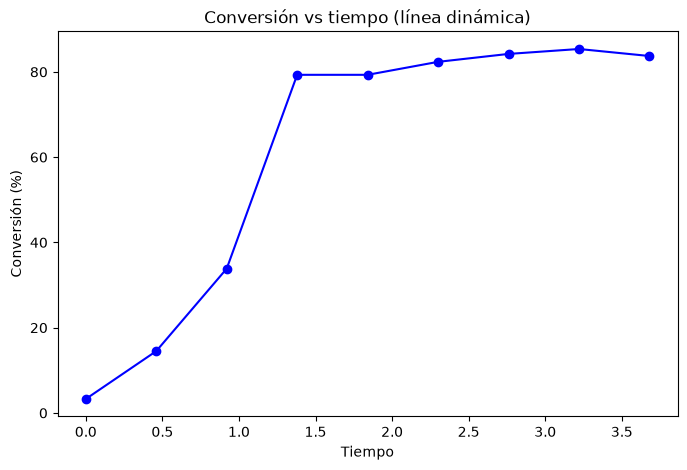

In [12]:
# plot_conversion acepta directamente los snapshots (t, heights, conversion)
plotter.plot_conversion(snaps, title="Conversión vs tiempo (línea dinámica)")

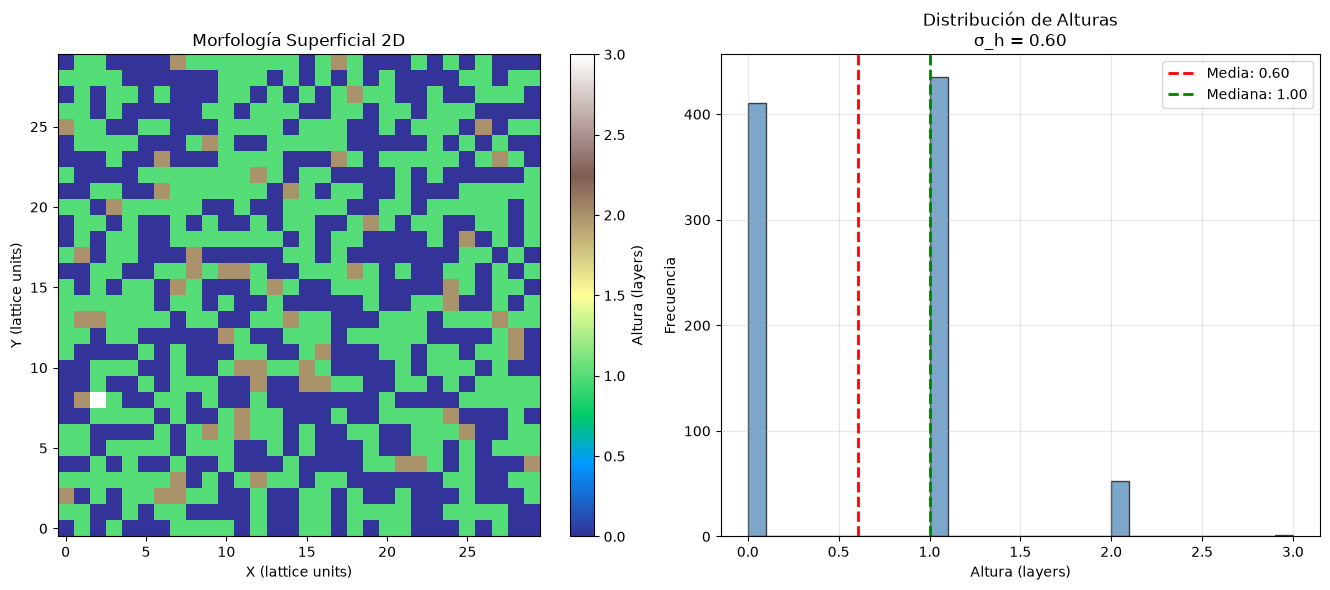

In [13]:
plotter.plot_surface_morphology()

`plot_growth_rate_analysis` y `plot_adsorption_probabilities` necesitan el `stats` de
la línea estática y no se usan aquí.

## 8. GIF del crecimiento

💾 GIF guardado en: /tmp/tmp4lj86rie/linea_dinamica.gif


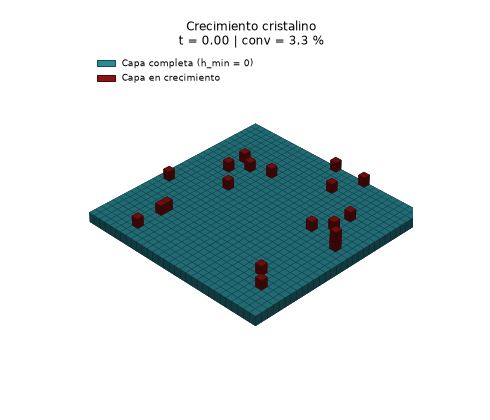

In [14]:
gif_path = Path(tempfile.mkdtemp()) / "linea_dinamica.gif"
plotter.crystal_growth_gif(snaps, save_path=str(gif_path), fps=3, dpi=70)
display(Image(filename=str(gif_path)))

## 9. Comprobaciones

La validación fuerte de la refactorización está en `tests/`: `test_golden.py` compara
bit a bit con el código original. Aquí solo se comprueban invariantes del uso normal:

1. cada evento queda registrado una sola vez;
2. conservación: partículas en la red + reservorio = N_bulk0;
3. la S reconstruida desde el historial coincide con la del motor;
4. determinismo: con las mismas semillas se obtiene la misma trayectoria, que además
   coincide con el comienzo de la corrida principal.

In [15]:
# 1) Registro de eventos
assert sum(kmc.counts.values()) == len(kmc.history)

# 2) Conservación red + reservorio
assert kmc.lat.heights.sum() + kmc.N_bulk == N_BULK0
assert masa_ev[-1] == kmc.lat.heights.sum()

# 3) S reconstruida == S del motor
assert np.isclose(S_ev[-1], kmc.supersaturation)

# 4) Determinismo
N_DET = 300
a = crear_motor(); a.run(t_end=np.inf, max_events=N_DET)
b = crear_motor(); b.run(t_end=np.inf, max_events=N_DET)
assert np.array_equal(a.lat.heights, b.lat.heights) and a.history == b.history
assert kmc.history[:N_DET] == a.history

print("✅ Todas las comprobaciones pasan")

✅ Todas las comprobaciones pasan
